# Regresión Logística
## (Clasificación binaria con probabilidades)

La **Regresión Logística** es un modelo lineal para clasificación binaria que, en lugar de predecir directamente una clase, estima la **probabilidad** de pertenecer a la clase positiva.

## Idea central

Primero se calcula una combinación lineal:

$$
z = w^T x + b
$$

Luego se transforma a probabilidad mediante la **función sigmoide**:

$$
P(y=1\mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Finalmente, se decide la clase usando un umbral (típicamente 0.5):

$$
\hat{y} =
\begin{cases}
1 & \text{si } P(y=1\mid x) \ge 0.5 \\
0 & \text{si } P(y=1\mid x) < 0.5
\end{cases}
$$

## Interpretación geométrica

La frontera de decisión sigue siendo lineal:

$$
w^T x + b = 0
$$

- En **2D**, es una **línea**.
- En **3D**, es un **plano**.
- En dimensiones superiores, un **hiperplano**.

## Cuándo funciona bien

- Cuando las clases son aproximadamente separables con una frontera lineal.
- Cuando interesa interpretar pesos y/o probabilidades.

## Limitaciones

- Si la frontera real es muy curva, se requerirán transformaciones o modelos no lineales.
- Sensible a escala de variables (se recomienda estandarización).

## Qué se observará en este notebook

1. Se cargará un dataset sintético.
2. Se entrenará un modelo de **Regresión Logística** con `scikit-learn`.
3. Se evaluará el desempeño en test y se visualizarán resultados.

In [1]:
# Cell 1 — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Cell 2 — Importando módulo propio

from utils.classification_functions import *

In [5]:
# Cell 3 — Leyendo datos

DATA_FILE = "binary_classification_separable_3d.csv"  # cambiar aquí

data_path = Path("../data/mocked_data") / DATA_FILE
df = pd.read_csv(data_path)

X = df.drop(columns=["y"])
y = df["y"]

print(f"Dataset loaded: {DATA_FILE}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded: binary_classification_separable_3d.csv
Shape: (10000, 4)


,x1,x2,x3,y
0,-0.089699,1.313391,-3.115777,0
1,-0.718095,2.546880,-2.033826,0
2,-1.511018,3.531431,-1.418384,0
3,-0.722646,3.548436,-1.535807,0
4,-1.530624,3.172766,-2.843698,0


## Dividiendo Datos

In [6]:
# Cell 4 — Train/Test split (80/20, shuffle, seed)

TEST_SIZE = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (8000, 3)
Test set: (2000, 3)


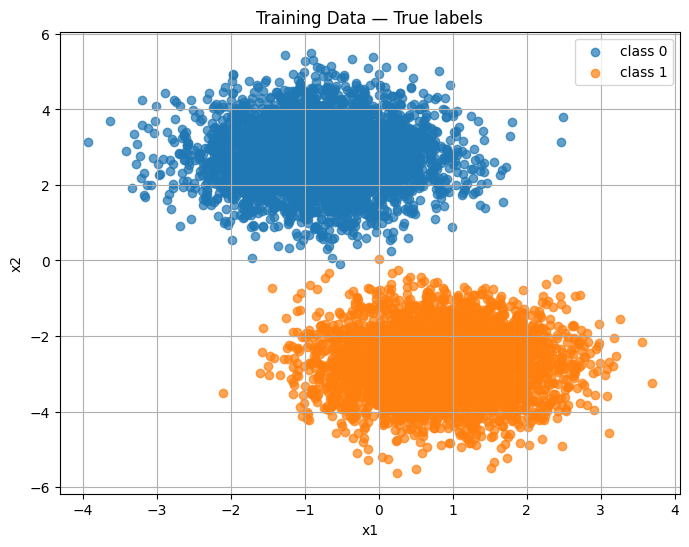

In [7]:
# Cell 5 — Plot Training

plot_points(
    X_train.to_numpy(),
    y_train.to_numpy(),
    dims=2,
    title="Training Data — True labels"
)

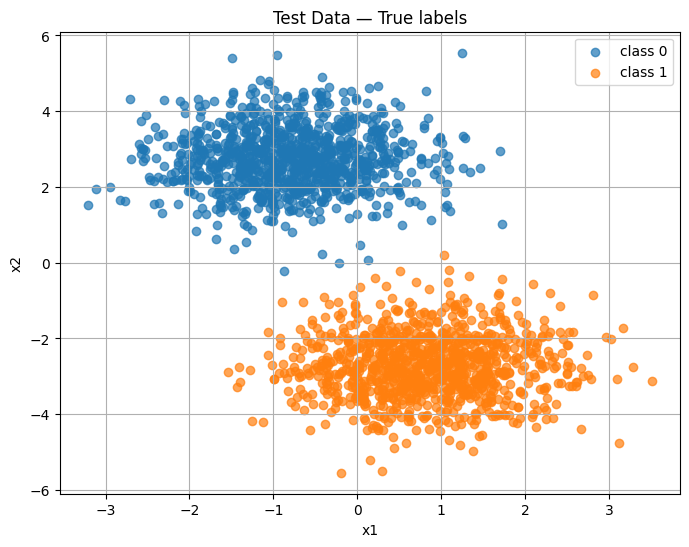

In [8]:
# Cell 6 — Plot Test

plot_points(
    X_test.to_numpy(),
    y_test.to_numpy(),
    dims=2,
    title="Test Data — True labels"
)

## Entrenando modelo de Regresión Logística

In [9]:
# Cell 7 — Hiperparámetros

LOGREG_PARAMS = {
    "penalty": "l2",          # "l2" | "l1" | "elasticnet" | None (depende del solver)
    "C": 1.0,                 # inverso de regularización (menor C => más regularización)
    "solver": "lbfgs",        # "lbfgs" (l2), "liblinear" (l1/l2), "saga" (l1/l2/elasticnet)
    "max_iter": 2000,
    "random_state": RANDOM_SEED
}

In [10]:
# Cell 8 — Entrenamiento (con escalamiento)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(**LOGREG_PARAMS))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [12]:
# Cell 9 — Parámetros aprendidos

clf = model.named_steps["logreg"]

print("LogisticRegression object:\n")
print(clf)

print("\nLearned attributes:")
print("coef_.shape:", clf.coef_.shape)
print("coef_:", clf.coef_)
print("intercept_.shape:", clf.intercept_.shape)
print("intercept_:", clf.intercept_)

LogisticRegression object:

LogisticRegression(max_iter=2000, penalty='l2', random_state=42)

Learned attributes:
coef_.shape: (1, 3)
coef_: [[ 1.12146937 -4.94541376  3.72283315]]
intercept_.shape: (1,)
intercept_: [0.04061855]


Test Accuracy: 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



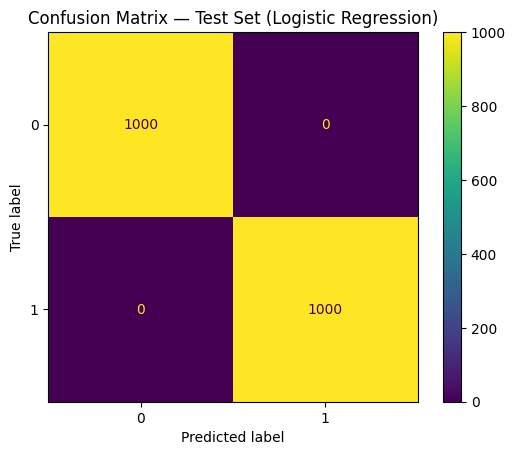

In [13]:
# Cell 10 — Evaluación en test

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix — Test Set (Logistic Regression)")
plt.show()

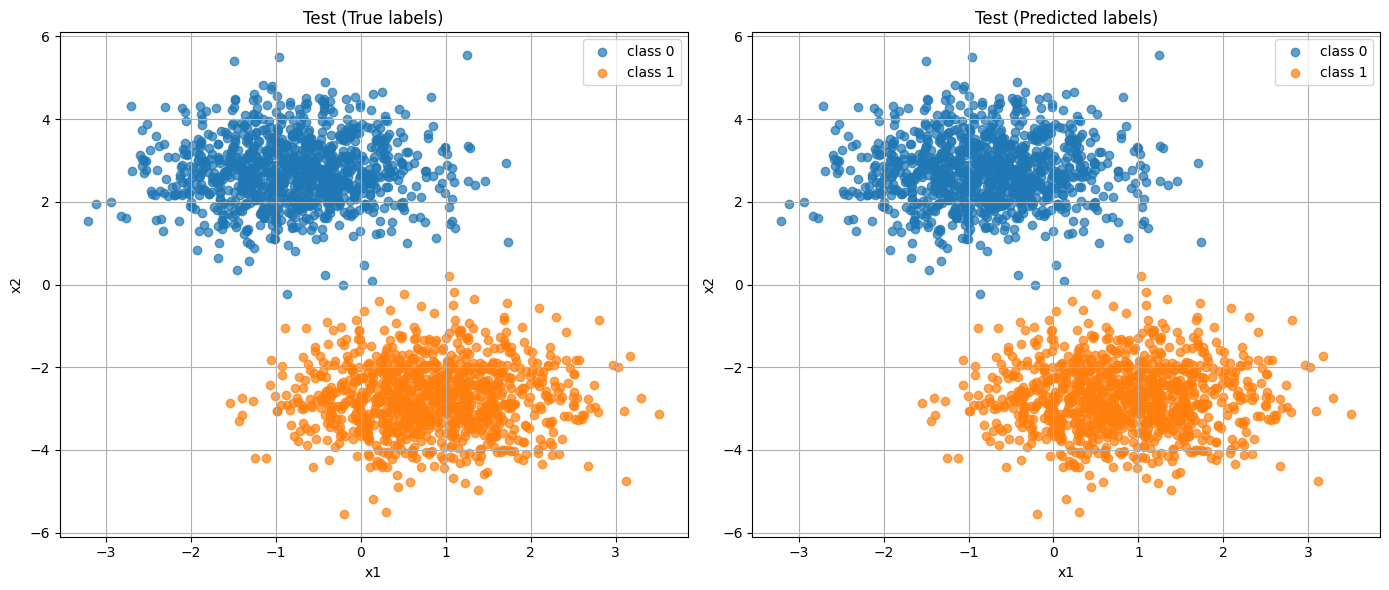

In [14]:
# Cell 11 — Visualizando resultados (True vs Pred)

plot_true_vs_pred(
    X_test,
    y_test,
    y_pred,
    dims=2,      # cambiar a 3 si se usa dataset 3D
    elev=25,
    azim=45
)